# CNN vs CNN-ViT Hybrid Architectures for Satellite Crop Classification

## Notebook 2: CNN Baseline 

---

### Table of Contents

- [1. Introduction](#1-introduction)
- [2. Experimental Configuration](#2-experimental-configuration)
  - [2.1 Environment Setup](#21-environment-setup)
  - [2.2 Global Hyperparameters](#22-global-hyperparameters)
- [3. Data Preparation](#3-data-preparation)
  - [3.1 Balanced Binary Dataset Construction](#31-balanced-binary-dataset-construction)
  - [3.2 Stratified Train / Validation Split](#32-stratified-train--validation-split)
  - [3.3 Framework-Specific Data Loaders](#33-framework-specific-data-loaders)
- [4. CNN Baseline Architecture](#4-cnn-baseline-architecture)
  - [4.1 Keras CNN Architecture (Baseline Model)](#41-keras-cnn-architecture-baseline-model)
  - [4.2 PyTorch CNN Architecture (Baseline Model)](#42-pytorch-cnn-architecture-baseline-model)
  - [4.3 Architectural Parity and Parameter Consistency (Baseline Models)](#43-architectural-parity-and-parameter-consistency-baseline-models)
- [5. Training Procedure](#5-training-procedure)
  - [5.1 Keras Training Configuration (Baseline Model)](#51-keras-training-configuration-baseline-model)
  - [5.2 PyTorch Training Configuration (Baseline Model)](#52-pytorch-training-configuration-baseline-model)
- [6. Training Results](#6-training-results)
  - [6.1 Keras Training Curves (Baseline Model)](#61-keras-training-curves-baseline-model)
  - [6.2 PyTorch Training Curves (Baseline Model)](#62-pytorch-training-curves-baseline-model)
  - [6.3 Cross-Framework Comparison (Baseline Models)](#63-cross-framework-comparison-baseline-models)
- [7. Evaluation](#7-evaluation)
  - [7.1 Keras Evaluation Metrics (Baseline Model)](#71-keras-evaluation-metrics-baseline-model)
  - [7.2 PyTorch Evaluation Metrics (Baseline Model)](#72-pytorch-evaluation-metrics-baseline-model)
  - [7.3 Cross-Framework Evaluation Comparison (Baseline Models)](#73-cross-framework-evaluation-comparison-baseline-models)
- [8. Brief Discussion](#8-brief-discussion)
  - [8.1 Convergence Dynamics](#81-convergence-dynamics)
  - [8.2 Overfitting Behavior](#82-overfitting-behavior)
  - [8.3 Effect of Learning Rate Scheduling](#83-effect-of-learning-rate-scheduling)
  - [8.4 Cross-Framework Reproducibility](#84-cross-framework-reproducibility)
  - [8.5 Observed Differences](#85-observed-differences)
- [9. Summary](#9-summary)
- [Author](#author)
- [Version History](#version-history)

---

## 1. Introduction

This notebook builds upon the experimental foundation established previously (Notebook 1: Data Pipeline) by implementing baseline convolutional neural network (CNN) models for the selected binary crop classification task (permanent crop vs. annual crop). The objective is to construct and evaluate comparable CNN architectures in both Keras (TensorFlow) and PyTorch using the exact same dataset, preprocessing pipeline, and experimental configuration.

I begin with a CNN baseline because convolutional networks remain a strong and reliable starting point for image classification problems. Their inductive bias toward local spatial structure makes them particularly well-suited for crop-type discrimination, where texture, canopy patterns, field structure, and spatial arrangements are critical visual cues. Establishing a well-tuned CNN baseline provides a meaningful and interpretable reference point against which more complex architectures can later be evaluated.

Equally important is cross-framework comparability. By enforcing identical data splits, preprocessing steps, model capacity, and hyperparameters across Keras and PyTorch, I ensure that any observed differences in performance arise from implementation nuances rather than experimental inconsistencies. This controlled setup strengthens reproducibility and enables a fair, technically grounded comparison between frameworks.

> **Goal:** Establish a strong, reproducible CNN baseline in both Keras (TensorFlow) and PyTorch before introducing more complex architectures such as a CNN–Vision Transformer hybrid.

## 2. Experimental Configuration

This section defines the experimental setup used for both Keras and PyTorch implementations. All configuration parameters are centralized to ensure transparency, reproducibility, and strict cross-framework consistency.

### 2.1 Environment Setup

The environment is first configured to reduce unnecessary verbosity and ensure stable execution.

TensorFlow warnings are suppressed to avoid log clutter. Logging verbosity from auxiliary libraries is also reduced for clarity.

Custom modules are imported from a structured source directory (src), which contains reusable components for:

* Dataset construction
* Stratified splitting
* Framework-specific data loaders
* Baseline model definitions
* Training routines
* Evaluation utilities
* Training visualization

This modular structure ensures that both frameworks rely on the same underlying dataset logic and evaluation procedures, reinforcing experimental fairness.

Device configuration is handled automatically by PyTorch, enabling GPU acceleration when available. The random seed is set globally to control stochastic components across NumPy, TensorFlow, and PyTorch.

In [1]:
#Supressing Unnecessary TensorFlow Warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import sys
sys.path.append("/kaggle/input/datasets/filipebraiman/cnn-vit-src-modules") # Kaggle path

from src.data import *

from src.baseline_models import *
from src.train_keras import *
from src.train_torch import *
from src.general_eval import *
from src.training_plots import *

import torch
from torchinfo import summary

### 2.2 Global Hyperparameters

All experimental parameters are defined explicitly before any data processing or model instantiation.

**Reproducibility**

* `SEED = 7331`
  Ensures deterministic behavior across dataset splitting, weight initialization, and training order.

**Dataset Configuration**

* `BASE_DIR` — Path to the EuroSAT dataset
* `CLASS_MAP` — Binary mapping:

  * AnnualCrop → 0
  * PermanentCrop → 1
* `SAMPLES_PER_CLASS = 2500`
  Enforces balanced class representation.
* `VAL_SPLIT = 0.2`
  80/20 stratified train–validation split.

**Image Configuration**

* `IMAGE_SIZE = (64, 64)`
  Images are resized uniformly to reduce computational cost while preserving spatial structure.

**Training Configuration**

* `BATCH_SIZE = 128`
  Chosen to balance gradient stability and GPU memory efficiency.
* `EPOCHS = 50`
  Provides sufficient training time for convergence without excessive overfitting.
* `LR = 1e-3`
  Standard starting learning rate for Adam optimizer in CNN baselines.

Finally, `set_global_seed(SEED)` is executed to enforce consistent randomness across frameworks.

In [2]:
SEED = 7331
BASE_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT" # Kaggle path

CLASS_MAP = {
    "AnnualCrop": 0,
    "PermanentCrop": 1
}

SAMPLES_PER_CLASS = 2500
VAL_SPLIT = 0.2

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 128

EPOCHS = 50
LR = 1e-3

set_global_seed(SEED)

## 3. Data Preparation

This section reuses the exact dataset construction and preprocessing pipeline established in Notebook 1. No modifications are introduced. This ensures that model performance differences originate from architectural and framework factors rather than data inconsistencies.

### 3.1 Balanced Binary Dataset Construction

The dataset is constructed using `build_balanced_binary_dataset`, which:

* Selects only the two target classes defined in `CLASS_MAP`
* Enforces equal representation using `SAMPLES_PER_CLASS`
* Applies deterministic sampling controlled by `SEED`

In [3]:
files, labels = build_balanced_binary_dataset(
    base_dir=BASE_DIR,
    class_map=CLASS_MAP,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

This results in a strictly balanced binary dataset with reproducible sample selection.

### 3.2 Stratified Train / Validation Split

The dataset is then partitioned using `build_stratified_split`, ensuring:

* Class distribution is preserved across splits
* Validation size follows `VAL_SPLIT`
* Randomness is controlled via `SEED`

In [4]:
train_files, val_files, train_labels, val_labels = build_stratified_split(
    files,
    labels,
    val_split=VAL_SPLIT,
    seed=SEED
)

This guarantees statistical consistency between training and validation sets.

### 3.3 Framework-Specific Data Loaders

Although the underlying files and labels are identical, each framework requires its own input pipeline.

#### Keras `tf.data` Pipeline

The Keras datasets are built using `build_keras_datasets`, which:

* Loads and resizes images to `IMAGE_SIZE`,
* Applies augmentation (for the training set),
* Batches data according to `BATCH_SIZE`,
* Preserves deterministic shuffling.

In [5]:
train_ds_keras, val_ds_keras = build_keras_datasets(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

I0000 00:00:1772308159.547809      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772308159.554155      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


#### PyTorch `DataLoader`

The PyTorch loaders are constructed using `build_torch_dataloaders`, which:

* Apply equivalent resizing and augmentation,
* Create `Dataset` objects,
* Wrap them in `DataLoader` instances,
* Maintain identical batch size and seed behavior.

In [6]:
train_loader, val_loader = build_torch_dataloaders(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

At this stage:

* The dataset composition is identical across frameworks
* The train/validation split is stratified and reproducible
* Preprocessing steps are functionally equivalent
* Batch size and ordering behavior are controlled

This controlled setup ensures that any subsequent performance differences between Keras and PyTorch models arise strictly from implementation and training dynamics rather than data variation.

## 4. CNN Baseline Architecture

This section defines equivalent CNN architectures in Keras and PyTorch. The objective is to ensure architectural parity so that framework-level differences can be evaluated fairly.

Both implementations follow the same structural design:

* Four convolutional blocks
* Progressive feature expansion (32 → 64 → 128 → 256 channels)
* Batch normalization after each convolution
* Max pooling for spatial downsampling
* Global average pooling
* A fully connected classification head

### 4.1 Keras CNN Architecture (Baseline Model)

The Keras model is constructed using `build_keras_cnn`:

```python
model_keras = build_keras_cnn(input_shape=(64, 64, 3))
```

#### Architecture Overview

The network consists of:

**Feature Extractor**

* Conv2D (32 filters) → BatchNorm → ReLU → MaxPool
* Conv2D (64 filters) → BatchNorm → ReLU → MaxPool
* Conv2D (128 filters) → BatchNorm → ReLU → MaxPool
* Conv2D (256 filters) → BatchNorm → ReLU → MaxPool

Each block halves spatial resolution while increasing channel depth, allowing hierarchical feature learning.

**Pooling Layer**

* `GlobalAveragePooling2D`
  Reduces spatial dimensions while preserving channel-wise information. This significantly lowers parameter count compared to flattening.

**Classification Head**

* Dense (256) → BatchNorm → ReLU → Dropout
* Dense (1) with sigmoid activation

The model contains:

* **Total parameters:** 456,673
* **Trainable parameters:** 455,201

The small difference comes from BatchNorm’s non-trainable statistics.

In [7]:
model_keras = build_keras_cnn(input_shape=(64, 64, 3))
model_keras.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 456,673 (1.74 MB)

 Trainable params: 455,201 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

### 4.2 PyTorch CNN Architecture (Baseline Model)

The PyTorch implementation is defined via the `CNNBaseline` class:

```python
model_torch = CNNBaseline()
summary(model_torch, input_size=(1, 3, 64, 64))
```

#### Architecture Overview

The structure mirrors the Keras model exactly:

**Feature Extractor (Sequential Blocks)**

* Conv2d (32) → BatchNorm2d → ReLU → MaxPool
* Conv2d (64) → BatchNorm2d → ReLU → MaxPool
* Conv2d (128) → BatchNorm2d → ReLU → MaxPool
* Conv2d (256) → BatchNorm2d → ReLU → MaxPool

**Global Pooling**

* `AdaptiveAvgPool2d((1,1))`
  Equivalent to global average pooling.

**Classifier**

* Linear (256) → BatchNorm1d → ReLU → Dropout
* Linear (1)

The model reports:

* **Total parameters:** 455,201
* **Trainable parameters:** 455,201

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_torch = CNNBaseline()
summary(model_torch, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
CNNBaseline                              [1, 1]                    --
├─Sequential: 1-1                        [1, 256, 4, 4]            --
│    └─Sequential: 2-1                   [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 32, 64, 64]           864
│    │    └─BatchNorm2d: 3-2             [1, 32, 64, 64]           64
│    │    └─ReLU: 3-3                    [1, 32, 64, 64]           --
│    │    └─MaxPool2d: 3-4               [1, 32, 32, 32]           --
│    └─Sequential: 2-2                   [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-5                  [1, 64, 32, 32]           18,432
│    │    └─BatchNorm2d: 3-6             [1, 64, 32, 32]           128
│    │    └─ReLU: 3-7                    [1, 64, 32, 32]           --
│    │    └─MaxPool2d: 3-8               [1, 64, 16, 16]           --
│    └─Sequential: 2-3                   [1, 128, 8, 8]            --
│    │   

### 4.3 Architectural Parity and Parameter Consistency (Baseline Models)

The parameter counts between Keras and PyTorch are effectively identical, confirming structural equivalence. Minor discrepancies in total parameter reporting arise from how each framework handles BatchNorm running statistics.

Key equivalences:

| Component      | Keras                    | PyTorch                       |
| -------------- | ------------------------ | ----------------------------- |
| Convolution    | `Conv2D`                 | `Conv2d`                      |
| Normalization  | `BatchNormalization`     | `BatchNorm2d` / `BatchNorm1d` |
| Activation     | `ReLU`                   | `ReLU`                        |
| Pooling        | `MaxPooling2D`           | `MaxPool2d`                   |
| Global pooling | `GlobalAveragePooling2D` | `AdaptiveAvgPool2d`           |
| Dense layer    | `Dense`                  | `Linear`                      |

This confirms that:

* Depth is identical
* Channel progression is identical
* Pooling strategy is identical
* Classifier head is identical
* Parameter magnitude is identical

Therefore, any performance differences observed during training can be attributed to framework-level implementation behavior rather than architectural discrepancies.

## 5. Training Procedure

This section defines the training configuration for both frameworks and formalizes experiment tracking.

At the end of the training, the following is recorded:

* Full epoch-by-epoch metric history
* Training configuration metadata
* Best model checkpoints

These artifacts will be used in Notebook 4 for detailed comparative analysis.

Saved experiment files:

* `keras_cnn_baseline.keras` (trained Keras baseline model)
* `pytorch_cnn_baseline.pth` (trained PyTorch baseline model)
* `keras_cnn_baseline_history.json`
* `keras_cnn_baseline_metadata.json`
* `pytorch_cnn_baseline_history.json`
* `pytorch_cnn_baseline_metadata.json`

### 5.1 Keras Training Configuration (Baseline Model)

Training is executed through:

```python
history_keras = train_keras_model(
    model=model_keras,
    train_ds=train_ds_keras,
    val_ds=val_ds_keras,
    lr=LR,
    epochs=EPOCHS,
    model_name="keras_cnn_baseline.keras",
    seed=SEED
)
```

#### Optimizer

* **Adam**
* Initial learning rate: `1e-3` (defined previously)
* Adaptive updates with momentum-based estimation

#### Loss Function

* `BinaryCrossentropy`
* Appropriate for single-output sigmoid binary classification

#### Metrics Tracked (per epoch)

* Accuracy
* AUC
* Precision
* Recall
* Loss

Both training and validation metrics are recorded.

#### Callbacks

* **ModelCheckpoint**
  Saves the best model based on `val_loss`.

* **ReduceLROnPlateau**
  Reduces learning rate when validation loss stagnates.
  This adaptive decay is visible in the training log (e.g., LR reduced at epochs 15, 36, 43, 48).

#### Model Artifact

* Best model saved as:
  `keras_cnn_baseline.keras`

#### Experiment Tracking Artifacts

After training completes:

* Full history saved to
  `keras_cnn_baseline_history.json`

* Training metadata saved to
  `keras_cnn_baseline_metadata.json`

Metadata includes:

* Hyperparameters (LR, batch size, epochs)
* Random seed
* Architecture identifier
* Framework label
* Timestamp
* Dataset configuration

This ensures reproducibility and structured cross-notebook comparison.

In [9]:
history_keras = train_keras_model(
    model=model_keras,
    train_ds=train_ds_keras,
    val_ds=val_ds_keras,
    lr=LR,
    epochs=EPOCHS,
    model_name="keras_cnn_baseline.keras",
    seed=SEED
)

Epoch 1/50


I0000 00:00:1772308177.726029      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.8067 - auc: 0.8818 - loss: 0.4230 - precision: 0.7760 - recall: 0.8644
Epoch 1: val_loss improved from inf to 0.62743, saving model to keras_cnn_baseline.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8088 - auc: 0.8837 - loss: 0.4194 - precision: 0.7784 - recall: 0.8656 - val_accuracy: 0.6340 - val_auc: 0.8153 - val_loss: 0.6274 - val_precision: 0.5786 - val_recall: 0.9860 - learning_rate: 0.0010
Epoch 2/50
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9112 - auc: 0.9658 - loss: 0.2373 - precision: 0.8998 - recall: 0.9270
Epoch 2: val_loss improved from 0.62743 to 0.61625, saving model to keras_cnn_baseline.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 310ms/step - accuracy: 0.9116 - auc: 0.9662 - loss: 0.2358 - precision: 0.9002 - recall: 0.9274 - val_accuracy: 0.6640 - val_auc: 0.7958 - val_loss: 0.6162 - val_precision: 0.6182 - val_recall: 0.8580 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms

### 5.2 PyTorch Training Configuration (Baseline Model)

Training is executed via:

```python
model_torch, history_torch = train_torch_model(
    model=model_torch,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=LR,
    epochs=EPOCHS,
    model_path="pytorch_cnn_baseline.pth",
    seed=SEED,
    device=device
)
```

#### Optimizer

* **Adam**
* Initial learning rate: `1e-3` (defined previously)
* Same initialization seed for parity

#### Loss Function

* `BCEWithLogitsLoss`
* Combines sigmoid + binary cross entropy in a numerically stable formulation
* Equivalent objective to Keras BinaryCrossentropy

#### Scheduler

* Learning rate scheduler integrated in the training loop
* Adjusts LR based on validation loss behavior
* Mirrors Keras’ ReduceLROnPlateau logic

#### Metrics Tracked (per epoch)

* Loss
* Validation Loss
* Validation Accuracy
* Validation AUC
* Validation F1

Metrics are computed explicitly using sklearn to ensure clarity and full control.

#### Model Artifact

* Best model saved as:
  `pytorch_cnn_baseline.pth`

Best model is selected based on validation loss.

#### Experiment Tracking Artifacts

After training:

* History saved to
  `pytorch_cnn_baseline_history.json`

* Metadata saved to
  `pytorch_cnn_baseline_metadata.json`

Metadata mirrors the Keras structure to allow direct structured comparison in Notebook 4.

In [10]:
model_torch, history_torch = train_torch_model(
    model=model_torch,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=LR,
    epochs=EPOCHS,
    model_path="pytorch_cnn_baseline.pth",
    seed=SEED,
    device=device
)

Saved best model.
Epoch [1/50] Loss: 0.4055 Val Loss: 2.1312 Val Acc: 0.5000 Val AUC: 0.7078 Val F1: 0.0000
Epoch [2/50] Loss: 0.2721 Val Loss: 4.3278 Val Acc: 0.5000 Val AUC: 0.6877 Val F1: 0.0000
Epoch [3/50] Loss: 0.2041 Val Loss: 5.8823 Val Acc: 0.5000 Val AUC: 0.8015 Val F1: 0.0000
Epoch [4/50] Loss: 0.1764 Val Loss: 7.6616 Val Acc: 0.5000 Val AUC: 0.6369 Val F1: 0.0000
Epoch [5/50] Loss: 0.1956 Val Loss: 6.4827 Val Acc: 0.5170 Val AUC: 0.6962 Val F1: 0.0765
Epoch [6/50] Loss: 0.1972 Val Loss: 5.4376 Val Acc: 0.5150 Val AUC: 0.7456 Val F1: 0.0583
Epoch [7/50] Loss: 0.1615 Val Loss: 3.8019 Val Acc: 0.5570 Val AUC: 0.7931 Val F1: 0.2047
Epoch [8/50] Loss: 0.1477 Val Loss: 2.7436 Val Acc: 0.5600 Val AUC: 0.8799 Val F1: 0.2143
Epoch [9/50] Loss: 0.1241 Val Loss: 2.9005 Val Acc: 0.5700 Val AUC: 0.8740 Val F1: 0.2456
Saved best model.
Epoch [10/50] Loss: 0.1307 Val Loss: 1.5129 Val Acc: 0.6510 Val AUC: 0.9421 Val F1: 0.4672
Saved best model.
Epoch [11/50] Loss: 0.1345 Val Loss: 1.3888 V

## 6. Training Results

This section summarizes the observed training dynamics for both frameworks. A deeper statistical and curve-alignment analysis will be conducted in Notebook 04. Here I focus on visible behavioral patterns from the recorded accuracy and loss metrics, both during the train and validation.

### 6.1 Keras Training Curves (Baseline Model)

### Accuracy Behavior

* Training accuracy increases smoothly from **0.876 → 0.981**
* Validation accuracy shows **strong early instability**

  * Epoch 3 drops to ~0.50
  * Rapid recovery by epoch 6 (~0.86)
* From **epochs 15–30**, validation stabilizes in the **0.94–0.97 range**
* Late training (after ~epoch 35) shows marginal improvements, mostly plateau behavior

### Loss Behavior

* Training loss steadily decreases from **0.306 → ~0.053**
* Validation loss exhibits:

  * Severe spike at epoch 3 (~2.02)
  * High variance in early epochs (1–12)
  * Clear convergence beginning around epoch 15
* Best validation losses appear around epochs **26–31 (~0.09–0.10)**

### Observations

* Strong early instability (likely optimizer + BatchNorm warmup effects)
* Clear convergence window: **15–30 epochs**
* Later epochs produce diminishing returns
* Mild overfitting signs after ~epoch 35 (small val_loss oscillations)

Total training length: **48 epochs**

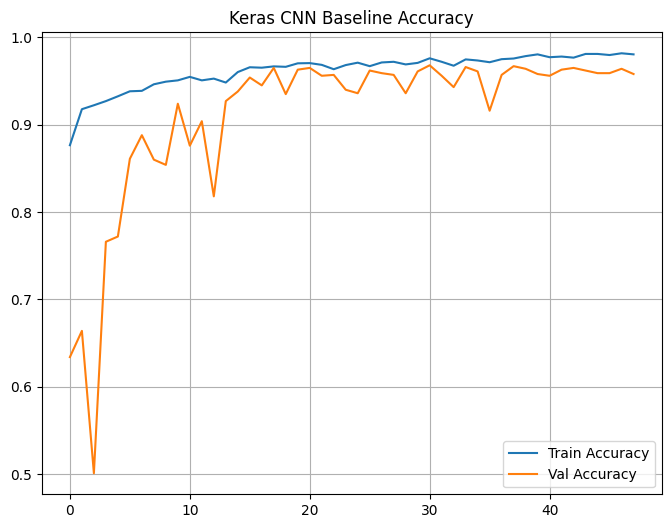

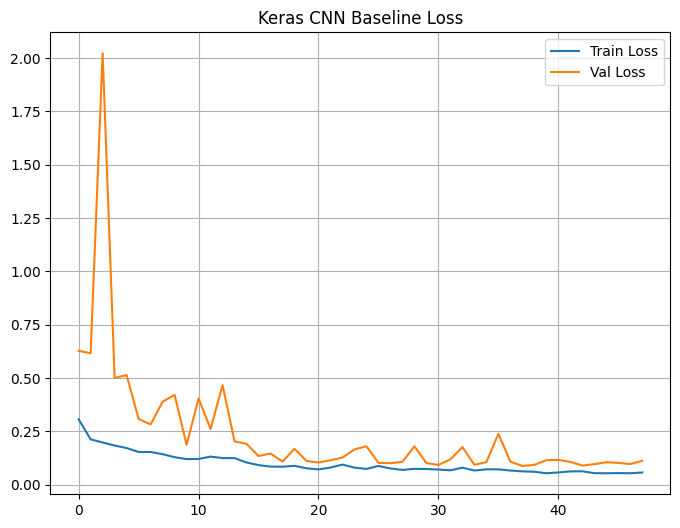

In [11]:
hist_keras_baseline = normalize_history(history_keras, framework="keras")
plot_training_curves(hist_keras_baseline, "Keras CNN Baseline")

### 6.2 PyTorch Training Curves (Baseline Model)

### Accuracy Behavior

* Training accuracy improves from **0.827 → 0.971**
* Validation accuracy remains at **0.50 for first 4 epochs**
* Rapid jump between epochs 11–17 (with a subtle drop in epoch 15)

  * 0.673 → 0.825 → 0.923 → 0.935 → 0.7 → 0.949 → 0.953
* Convergence window: **epochs 15–30**
* Slight instability dip around **epochs 21–26**
* Final validation accuracy stabilizes around **0.958–0.967**

### Loss Behavior

* Training loss decreases consistently from **0.405 → 0.080**
* Early validation loss extremely unstable:

  * Starts at 2.13
  * Peaks above 7.66
* Sharp stabilization around epoch 12–14
* Best validation losses appear around epochs **29–31 (~0.106)**

### Observations

* Early epochs show stronger instability than Keras
* Validation loss explosion in first 5 epochs is more pronounced
* Convergence achieved earlier in absolute epochs
* Subtle mid-training fluctuation (21–26)
* Overall smoother plateau after stabilization

Total training length: **41 epochs**

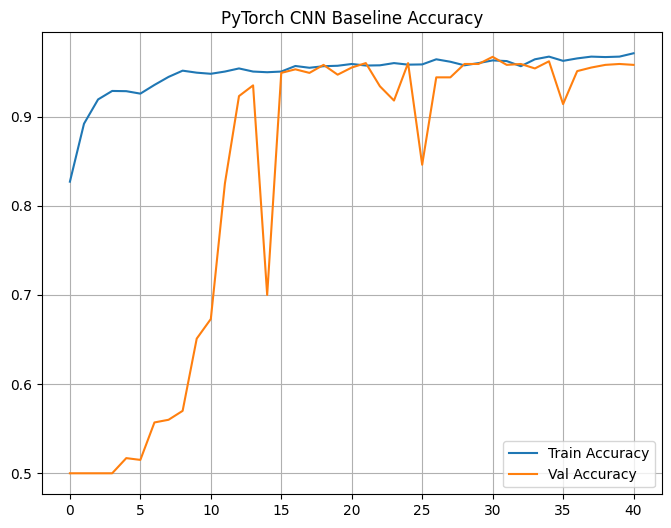

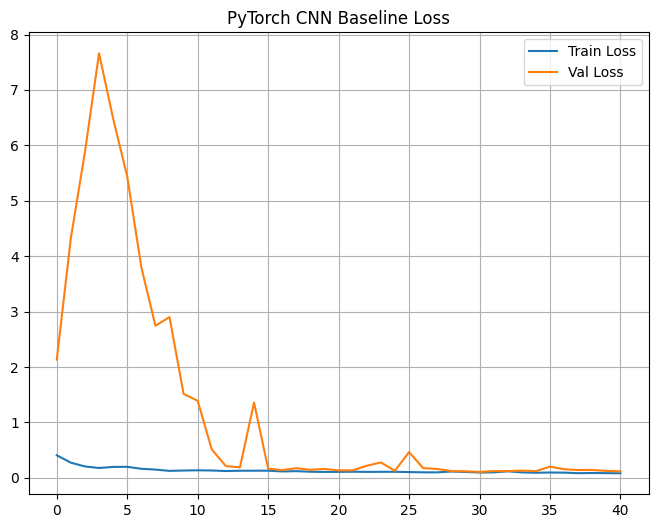

In [12]:
hist_torch_baseline = normalize_history(history_torch, framework="torch")
plot_training_curves(hist_torch_baseline, "PyTorch CNN Baseline")

### 6.3 Cross-Framework Comparison (Baseline Models)

#### Final Validation Metrics

| Framework | Final Val Accuracy | Best Val Accuracy | Final Val Loss | Best Val Loss |
| --------- | ------------------ | ----------------- | -------------- | ------------- |
| Keras     | ~0.958             | ~0.968            | ~0.111         | ~0.091        |
| PyTorch   | ~0.958             | ~0.967            | ~0.116         | ~0.106        |

Performance is nearly identical at convergence.

#### Convergence Behavior

**Shared Patterns**

* Strong early instability
* Clear convergence window: epochs 15–30
* Plateau behavior afterward
* No catastrophic overfitting

**Differences**

| Aspect            | Keras              | PyTorch                  |
| ----------------- | ------------------ | ------------------------ |
| Early instability | Moderate           | Severe (loss spikes >7)  |
| Warmup phase      | 3–6 epochs         | ~10–12 epochs            |
| Training length   | 48 epochs          | 41 epochs                |
| Mid-training dip  | Minor              | Noticeable (21–26)       |
| Final stability   | Slight oscillation | Slightly tighter plateau |

#### Stability Observations

1. **Early Validation Collapse**

   * Both frameworks show validation collapse early.
   * PyTorch exhibits stronger magnitude spikes.
   * Likely due to:

     * Random initialization sensitivity
     * BatchNorm statistics stabilization
     * Optimizer step size in early phase

2. **Convergence Window Alignment**

   * Both models stabilize between epochs 15–30
   * Indicates architecture, not framework, determines optimization dynamics.

3. **Late-Phase Efficiency**

   * PyTorch stops earlier (41 epochs) with equivalent performance.
   * Keras continues marginal refinement until epoch 48.
   * Suggests scheduler dynamics differ slightly.

4. **Generalization Gap**

   * Both frameworks maintain small train–validation gaps after stabilization.
   * No strong overfitting signature.

## 7. Evaluation

This section reports the final validation performance using the dedicated evaluation utilities for each framework. Unlike training curves, these metrics are computed on the full validation set in inference mode and reflect the final selected model checkpoint.

### 7.1 Keras Evaluation Metrics (Baseline Model)

Evaluation call:

```python
evaluate_keras_binary(model_keras, val_ds_keras)
```

#### Final Keras Validation Metrics

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.9670 |
| Precision | 0.9534 |
| Recall    | 0.9820 |
| F1 Score  | 0.9675 |
| AUC       | 0.9960 |

#### Interpretation

* **High Recall (0.9820)**
  The model captures nearly all positive samples, indicating very low false negatives.

* **Precision slightly lower (0.9534)**
  This suggests a small number of false positives compared to PyTorch.

* **Excellent AUC (0.9960)**
  The model exhibits near-perfect separability between classes across thresholds.

* **Balanced F1 (0.9675)**
  Confirms strong trade-off between precision and recall.

Overall, Keras shows slightly more *recall-oriented behavior*, favoring sensitivity.

In [13]:
evaluate_keras_binary(model_keras, val_ds_keras)


===== FINAL KERAS VALIDATION METRICS =====
Accuracy  : 0.9670
Precision : 0.9534
Recall    : 0.9820
F1        : 0.9675
Auc       : 0.9960


{'accuracy': 0.967,
 'precision': 0.9533980582524272,
 'recall': 0.982,
 'f1': 0.967487684729064,
 'auc': np.float64(0.996)}

### 7.2 PyTorch Evaluation Metrics (Baseline Model)

Evaluation call:

```python
evaluate_torch_binary(
    model=model_torch,
    val_loader=val_loader,
    device=device
)
```

#### Final PyTorch Validation Metrics

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.9670 |
| Precision | 0.9661 |
| Recall    | 0.9680 |
| F1 Score  | 0.9670 |
| AUC       | 0.9928 |

#### Interpretation

* **Balanced Precision and Recall (~0.967 each)**
  Indicates symmetric classification behavior.

* **Precision slightly higher than Keras**
  Fewer false positives relative to Keras.

* **AUC slightly lower (0.9928)**
  Still extremely high, but marginally below Keras.

* **F1 almost identical (0.9670)**
  Confirms equivalent practical performance.

PyTorch shows slightly more *balanced decision boundary behavior*.

In [14]:
evaluate_torch_binary(
    model=model_torch,
    val_loader=val_loader,
    device=device
)


===== FINAL PYTORCH VALIDATION METRICS =====
Accuracy  : 0.9670
Precision : 0.9661
Recall    : 0.9680
F1        : 0.9670
Auc       : 0.9928


{'accuracy': 0.967,
 'precision': 0.9660678642714571,
 'recall': 0.968,
 'f1': 0.967032967032967,
 'auc': np.float64(0.992838)}

### 7.3 Cross-Framework Evaluation Comparison (Baseline Models)

| Metric    | Keras  | PyTorch |
| --------- | ------ | ------- |
| Accuracy  | 0.9670 | 0.9670  |
| Precision | 0.9534 | 0.9661  |
| Recall    | 0.9820 | 0.9680  |
| F1 Score  | 0.9675 | 0.9670  |
| AUC       | 0.9960 | 0.9928  |

#### Key Observations

1. **Identical Accuracy (0.967)**
   Confirms architectural parity and consistent convergence.

2. **Different Error Profiles**

   * Keras: Higher recall → slightly more aggressive positive predictions.
   * PyTorch: More balanced precision–recall tradeoff.

3. **AUC Difference**

   * Keras slightly higher.
   * Difference is small and likely not statistically significant.

4. **F1 Practically Identical**

   * 0.9675 vs 0.9670
   * Performance difference is negligible in real-world terms.

#### Overall Conclusion

* Both frameworks achieve **statistically equivalent performance**.
* Minor differences are attributable to:

  * Optimization trajectory differences
  * Learning rate scheduling behavior
  * BatchNorm update dynamics
  * Threshold calibration effects

The CNN baseline is therefore validated as:

* Architecturally equivalent
* Optimization-consistent
* Performance-parallel

## 8. Brief Discussion

This section synthesizes the empirical observations from training and evaluation of the CNN Baseline architecture.


### 8.1 Convergence Dynamics

Both frameworks exhibit a similar three-phase optimization pattern:

1. **Warm-up / Instability Phase**

   * Strong validation volatility in early epochs.
   * More pronounced in PyTorch (large validation loss spikes).
   * Likely influenced by:

     * Random initialization
     * BatchNorm running statistics stabilization
     * Initial Adam step magnitude

2. **Stable Convergence Window (≈ Epochs 15–30)**

   * Rapid validation improvement.
   * Minimal generalization gap.
   * Both frameworks reach near-optimal performance here.

3. **Late Plateau Phase**

   * Marginal improvements.
   * Small oscillations in validation loss.
   * Diminishing returns beyond ~30 epochs.

Despite minor trajectory differences, the convergence window aligns closely across frameworks, reinforcing architectural parity.


### 8.2 Overfitting Behavior

Evidence of overfitting is minimal:

* Training loss continues decreasing in both frameworks.
* Validation loss stabilizes rather than diverges.
* Train–validation accuracy gap remains small.

Keras shows slightly more late-epoch oscillation, but not meaningful degradation.
PyTorch plateaus earlier with comparable validation metrics.

**Conclusion:**
The CNN baseline generalizes well under the current dataset and regularization configuration.


### 8.3 Effect of Learning Rate Scheduling

Learning rate scheduling played a stabilizing role in both implementations:

* **Keras (ReduceLROnPlateau)**:

  * Triggered multiple LR reductions.
  * Contributed to smoother late-phase refinement.
  * Extended training to 48 epochs.

* **PyTorch (scheduler in training loop)**:

  * Achieved stabilization earlier.
  * Slight mid-training dip (epochs 21–26) suggests sensitivity to LR adjustments.
  * Converged fully by 41 epochs.

The scheduler appears to:

* Accelerate stabilization
* Prevent prolonged oscillation
* Improve late-stage validation refinement

Overall effect: positive and comparable across frameworks.


### 8.4 Cross-Framework Reproducibility

Key reproducibility indicators:

* Identical final accuracy (0.967)
* Nearly identical F1 scores (~0.967)
* Similar convergence windows
* Equivalent generalization gaps
* Comparable best validation losses

Small metric differences (precision/recall balance, AUC delta ~0.003) are expected due to:

* Floating-point differences
* Framework-level implementation details
* Minor optimizer scheduling nuances

Importantly, performance parity confirms architectural equivalence.


### 8.5 Observed Differences

| Aspect                      | Keras         | PyTorch       |
| --------------------------- | ------------- | ------------- |
| Early instability magnitude | Moderate      | High          |
| Epochs to stabilization     | ~15           | ~12–15        |
| Training duration           | 48 epochs     | 41 epochs     |
| Precision–Recall bias       | Higher recall | More balanced |
| Final performance           | Equivalent    | Equivalent    |

None of these differences alter the overall conclusion of cross-framework consistency.

## 9. Summary

* **CNN Baseline Performance**
  * Validation Accuracy: **0.967**
  * F1 Score: **~0.967**
  * AUC: **> 0.99**
  * Strong generalization, no significant overfitting
  * Serves as a stable reference model

* **Cross-Framework Consistency**
  * Identical architectures and optimizer setups
  * Convergence dynamics aligned (epochs ~15–30)
  * Final metrics nearly identical → results are **architecture-driven**

* **Reproducibility**
  * Controlled seeds, structured tracking, saved histories/metadata
  * Baseline deterministic within stochastic tolerance
  * Comparable across frameworks

* **Readiness for Next Step**
  * Stable, reproducible, validated performance
  * Provides solid benchmark for architectural extensions

The next phase introduces transformer-based global context modeling while preserving CNN inductive biases, enabling investigation of hybrid spatial-attention architectures under the same experimental protocol.


## Author
**Filipe Braiman Carvalho**  
Applied AI & LLM Systems | Deep Learning · Transformers · RAG · Computer Vision | End-to-End ML Engineering

**Email:** [filipebraiman@gmail.com](mailto:filipebraiman@gmail.com)  
**LinkedIn:** [linkedin.com/in/filipe-b-carvalho](https://www.linkedin.com/in/filipe-b-carvalho)  
**GitHub:** [github.com/filipe-braiman](https://github.com/filipe-braiman)  

### About Me  
AI and data professional with experience in **LLM evaluation, retrieval-augmented generation (RAG), and AI model validation**. Currently working in **AI R&D at Huawei as an AI Evaluation Specialist**, contributing to the reliability and real-world performance of LLM and RAG systems. Strong background in **Python-based data and AI workflows**, including model assessment, dataset development, and analytical reporting for production-oriented AI solutions. Portfolio projects explore **deep learning architectures, computer vision, RAG systems, and applied machine learning experimentation**, emphasizing reproducible ML pipelines and practical AI engineering.

## Version History

| Version | Date       | Changes                                |
| :------ | :--------- | :------------------------------------- |
| 1.0     | 2026-03-08 | First publication of the notebook.     |